In [ ]:
import torch

if torch.cuda.is_available():
    print("✅ GPU Available")
    print("Device :", torch.cuda.get_device_name(0))
else:
    print("❌ GPU Not Available")

✅ GPU Available
Device : Tesla T4


**Model 3: Vision Transformer (ViT-Base)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install timm
!pip -q install scikit-learn

In [ ]:
import os
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/research_data/train.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/research_data/val.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/research_data/test.csv")

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train : 8470
Validation : 1815
Test : 1815


In [ ]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.iloc[idx]["image_path"]
        label = self.dataframe.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
print(train_df.columns)
train_df.head()

Index(['image_path', 'label'], dtype='object')


,image_path,label
0,/content/drive/MyDrive/research_data/final_dat...,fake
1,/content/drive/MyDrive/research_data/final_dat...,fake
2,/content/drive/MyDrive/research_data/final_dat...,fake
3,/content/drive/MyDrive/research_data/final_dat...,fake
4,/content/drive/MyDrive/research_data/final_dat...,real


In [ ]:
class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "image_path"]

        label = self.df.loc[idx, "label"]

        # fake -> 0
        # real -> 1
        label = 1 if label == "real" else 0

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = BrainDataset(train_df, train_transform)
val_dataset   = BrainDataset(val_df, test_transform)
test_dataset  = BrainDataset(test_df, test_transform)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

8470
1815
1815


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 265
Validation batches : 57
Test batches : 57


In [ ]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

print(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5
)

print("Model Ready!")

Model Ready!


In [ ]:
print(device)
print(next(model.parameters()).device)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

cuda
cuda:0
265
57
57


In [ ]:
import time

start = time.time()

for i, (images, labels) in enumerate(train_loader):
    print("Batch:", i)
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    print("Forward Done")
    break

print("Time:", time.time() - start)

Batch: 0
Forward Done
Time: 50.189441204071045


In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/research_data/best_vit_timm.pth")
)
model.to(device)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)
loss = criterion(outputs, labels)

print("Forward Done")

loss.backward()

print("Backward Done")

optimizer.step()

print("Optimizer Done")

Forward Done
Backward Done
Optimizer Done


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

num_epochs = 5
best_val_acc = 0.0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(num_epochs):

    print("=" * 60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    ##############################
    # TRAINING
    ##############################
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx % 20 == 0:
            print(f"Training Batch {batch_idx}/{len(train_loader)}")

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    ##############################
    # VALIDATION
    ##############################
    model.eval()

    running_val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch_idx, (images, labels) in enumerate(val_loader):

            if batch_idx % 10 == 0:
                print(f"Validation Batch {batch_idx}/{len(val_loader)}")

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)

    val_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("-" * 40)
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    ##############################
    # SAVE BEST MODEL
    ##############################
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/research_data/best_vit_timm.pth"
        )

        print("✅ Best Model Saved")

    torch.cuda.empty_cache()

print("=" * 60)
print("Training Completed!")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

Epoch 1/5
Training Batch 0/265
Training Batch 20/265
Training Batch 40/265
Training Batch 60/265
Training Batch 80/265
Training Batch 100/265
Training Batch 120/265
Training Batch 140/265
Training Batch 160/265
Training Batch 180/265
Training Batch 200/265
Training Batch 220/265
Training Batch 240/265
Training Batch 260/265
Validation Batch 0/57
Validation Batch 10/57
Validation Batch 20/57
Validation Batch 30/57
Validation Batch 40/57
Validation Batch 50/57
----------------------------------------
Train Loss : 0.3023
Train Acc  : 0.8897
Val Loss   : 0.2643
Val Acc    : 0.9091
Precision  : 0.9899
Recall     : 0.7880
F1 Score   : 0.8775
✅ Best Model Saved
Epoch 2/5
Training Batch 0/265
Training Batch 20/265
Training Batch 40/265
Training Batch 60/265
Training Batch 80/265
Training Batch 100/265
Training Batch 120/265
Training Batch 140/265
Training Batch 160/265
Training Batch 180/265
Training Batch 200/265
Training Batch 220/265
Training Batch 240/265
Training Batch 260/265
Validation 

In [ ]:
!nvidia-smi

Tue Jul  7 05:12:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import time

start = time.time()

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print("Time:", time.time() - start)

torch.Size([32, 3, 224, 224])
torch.Size([32])
Time: 0.4125063419342041


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

model.load_state_dict(
    torch.load("/content/drive/MyDrive/research_data/best_vit_timm.pth")
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("="*50)
print("Test Results")
print("="*50)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(all_labels, all_preds))

print("\nConfusion Matrix\n")
print(confusion_matrix(all_labels, all_preds))

Test Results
Accuracy  : 0.9163
Precision : 0.9950
Recall    : 0.8013
F1 Score  : 0.8877

Classification Report

              precision    recall  f1-score   support

           0       0.88      1.00      0.93      1065
           1       1.00      0.80      0.89       750

    accuracy                           0.92      1815
   macro avg       0.94      0.90      0.91      1815
weighted avg       0.93      0.92      0.91      1815


Confusion Matrix

[[1062    3]
 [ 149  601]]


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/research_data/best_vit_timm.pth")
)

model.to(device)
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import torch

model.load_state_dict(torch.load("/content/drive/MyDrive/research_data/best_vit_timm.pth"))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))

Accuracy : 0.9162534435261708
Precision: 0.9950331125827815
Recall   : 0.8013333333333333
F1 Score : 0.8877400295420975


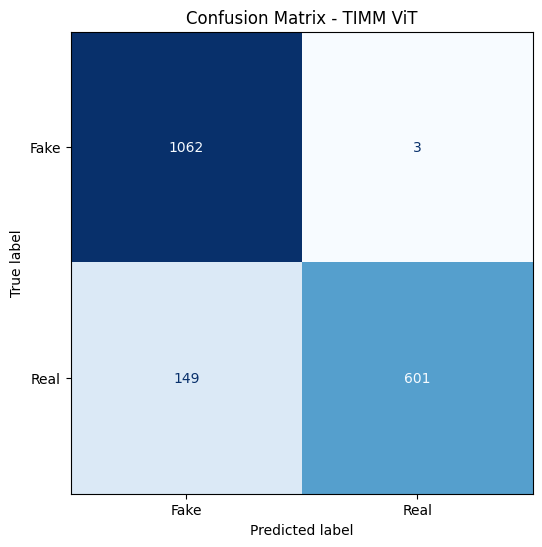

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - TIMM ViT")
plt.show()

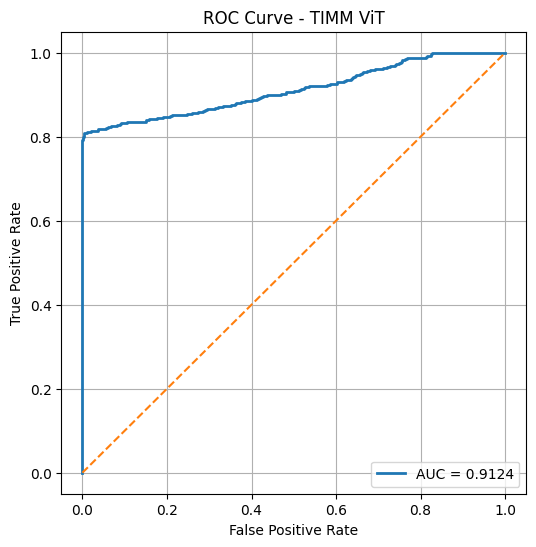

AUC Score : 0.9124


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TIMM ViT")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC Score : {roc_auc:.4f}")